[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2456
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


/opt/anaconda3/envs/ml-anaconda-python12-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml-anaconda-python12-env/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [02:15:27] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1748292887431/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


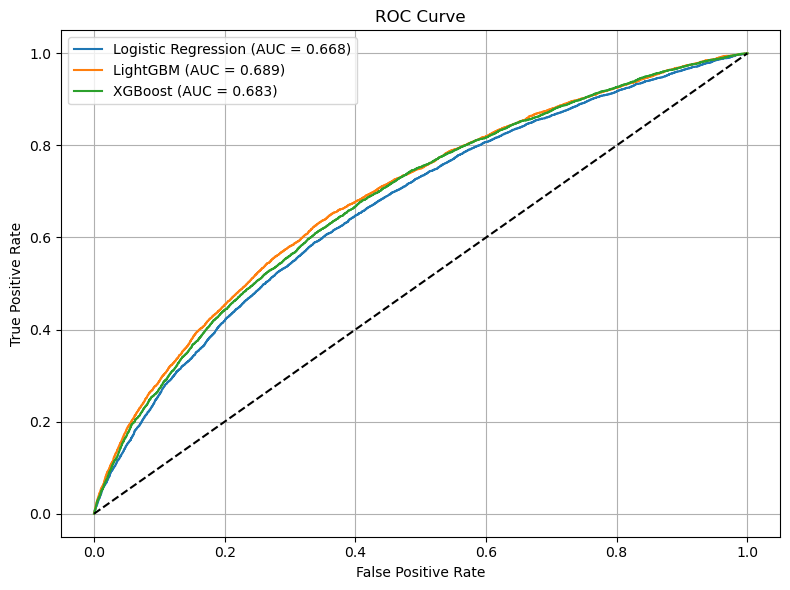

Evaluation Metrics:
                     Accuracy  Precision    Recall  F1-score       AUC
Logistic Regression  0.919532   0.500000  0.000202  0.000404  0.668095
LightGBM             0.919516   0.333333  0.000202  0.000404  0.689473
XGBoost              0.919110   0.240000  0.002425  0.004801  0.682887


In [2]:

# Credit Risk Modeling: Logistic Regression, LightGBM, XGBoost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, roc_curve
)
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt

# Đọc dữ liệu
data = pd.read_csv("./dataset/application_train.csv")

# Chọn các cột đặc trưng từ báo cáo
selected_features = [
    "CODE_GENDER", "DAYS_BIRTH", "NAME_FAMILY_STATUS", "CNT_CHILDREN",
    "CNT_FAM_MEMBERS", "NAME_EDUCATION_TYPE", "OCCUPATION_TYPE",
    "NAME_INCOME_TYPE", "REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY",
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH",
    "NAME_HOUSING_TYPE", "REGION_POPULATION_RELATIVE", "DAYS_LAST_PHONE_CHANGE",
    "TARGET"
]

df = data[selected_features].copy()

# One-hot encoding cho biến phân loại
df = pd.get_dummies(df, drop_first=True)

# Tách biến đầu vào và đầu ra
X = df.drop(columns="TARGET")
y = df["TARGET"]

# Xử lý missing value
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Huấn luyện và đánh giá từng mô hình
results = {}

def evaluate_model(name, model, X_test, y_test, y_pred_prob):
    y_pred = (y_pred_prob >= 0.5).astype(int)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_pred_prob)
    }

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", lr_model, X_test, y_test, lr_pred_prob)

# LightGBM
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
lgb_pred_prob = lgb_model.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM", lgb_model, X_test, y_test, lgb_pred_prob)

# XGBoost
xgb_model = xgb.XGBClassifier(eval_metric="logloss", use_label_encoder=False)
xgb_model.fit(X_train, y_train)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost", xgb_model, X_test, y_test, xgb_pred_prob)

# Biểu đồ ROC
plt.figure(figsize=(8, 6))
for name, pred in zip(["Logistic Regression", "LightGBM", "XGBoost"], 
                      [lr_pred_prob, lgb_pred_prob, xgb_pred_prob]):
    fpr, tpr, _ = roc_curve(y_test, pred)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, pred):.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Hiển thị kết quả đánh giá
results_df = pd.DataFrame(results).T
print("Evaluation Metrics:")
print(results_df)
